In [2]:
import urllib.request
from skimage import data, io, filters
import matplotlib.pyplot as plt
import cv2
import numpy as np

Available images in scikit-image:
['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


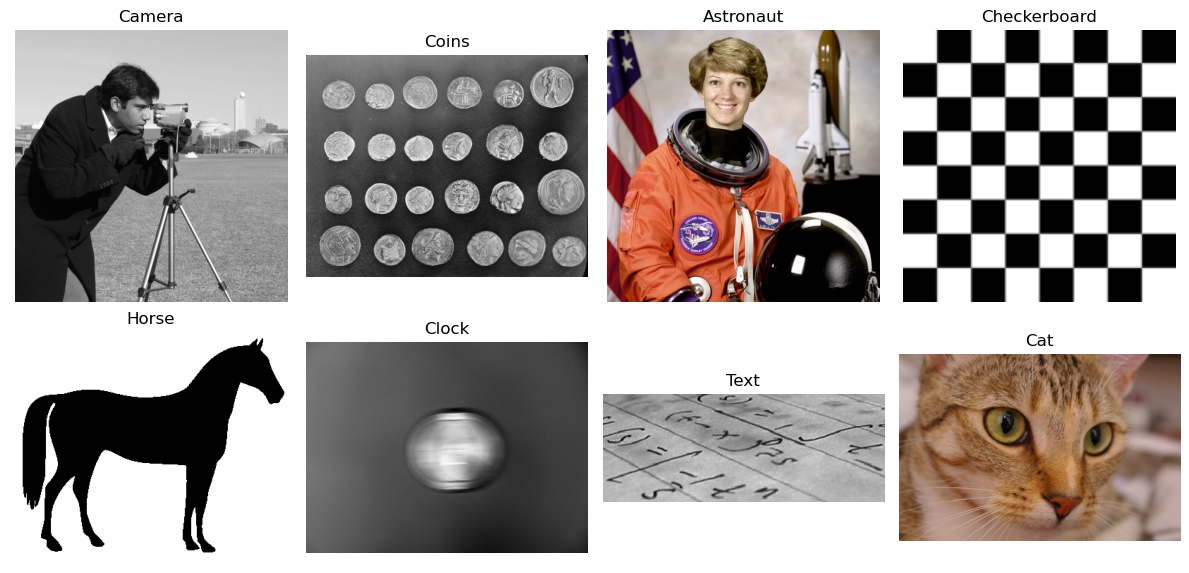

In [3]:

print("Available images in scikit-image:")
print(data.__all__)

camera = data.camera()          
coins = data.coins()            
astronaut = data.astronaut()    
checkerboard = data.checkerboard()  
horse = data.horse()                    
clock = data.clock()            
text = data.text()              
cat = data.cat()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
images = [camera, coins, astronaut, checkerboard, horse,  clock, text, cat]
titles = ['Camera', 'Coins', 'Astronaut', 'Checkerboard', 'Horse', 'Clock', 'Text', 'Cat']

for i, (ax, img, title) in enumerate(zip(axes.flat, images, titles)):
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
cat_bgr = cv2.cvtColor(cat, cv2.COLOR_RGB2BGR)
cv2.imshow('Cat (from skimage)', cat_bgr)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# Function to add Gaussian noise
def add_gaussian_noise(image, mean=0, sigma=25):
    row, col, ch = image.shape
    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = image + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

noisy_gaussian = add_gaussian_noise(cat_bgr)

cv2.imshow('Original', cat_bgr)
cv2.imshow('Gaussian Noise', noisy_gaussian)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# Function to add Salt & Pepper noise
def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy = np.copy(image)
    salt_mask = np.random.random(image.shape[:2]) < salt_prob
    noisy[salt_mask] = 255  
    pepper_mask = np.random.random(image.shape[:2]) < pepper_prob
    noisy[pepper_mask] = 0
    
    return noisy

noisy_sp = add_salt_pepper_noise(cat_bgr)

cv2.imshow('Original', cat_bgr)
cv2.imshow('Salt & Pepper Noise', noisy_sp)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
def add_poisson_noise(image):
    noise = np.random.poisson(image / 255.0 * 0.1) * 255
    noisy = image + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

noisy_poisson = add_poisson_noise(cat_bgr)
cv2.imshow('Original', cat_bgr)
cv2.imshow('Poisson Noise', noisy_poisson)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [1]:

flags = cv2.IMREAD_COLOR  
black_image = np.zeros((500, 500, 3), dtype=np.uint8)
white_image = np.ones((500, 500, 3), dtype=np.uint8) * 255
gradient = np.linspace(0, 255, 500, dtype=np.uint8)
gradient_image = np.tile(gradient, (500, 1))
colorful = np.zeros((300, 300, 3), dtype=np.uint8)
colorful[0:100, :] = [255, 0, 0]    
colorful[100:200, :] = [0, 255, 0]  
colorful[200:300, :] = [0, 0, 255] 
circle_image = np.zeros((400, 400, 3), dtype=np.uint8)
cv2.circle(circle_image, (200, 200), 100, (0, 255, 255), -1)
cv2.imshow('Black Image', black_image)
cv2.imshow('Colorful', colorful)
cv2.imshow('Circle', circle_image)
cv2.imshow('Gradient', gradient_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

NameError: name 'cv2' is not defined

In [15]:

def create_checkerboard(size=400, squares=8):
    checkerboard = np.zeros((size, size), dtype=np.uint8)
    square_size = size // squares
    
    for i in range(squares):
        for j in range(squares):
            if (i + j) % 2 == 0:
                checkerboard[i*square_size:(i+1)*square_size, 
                           j*square_size:(j+1)*square_size] = 255
    return checkerboard
checkerboard = create_checkerboard()
random_noise = np.random.randint(0, 256, (300, 300), dtype=np.uint8)
shapes_image = np.zeros((500, 500, 3), dtype=np.uint8)
cv2.rectangle(shapes_image, (50, 50), (200, 200), (255, 0, 0), -1)
cv2.circle(shapes_image, (350, 150), 80, (0, 255, 0), -1)
cv2.line(shapes_image, (100, 300), (400, 450), (0, 0, 255), 5)

cv2.imshow('Checkerboard', checkerboard)
cv2.imshow('Random Noise', random_noise)
cv2.imshow('Geometric Shapes', shapes_image)
cv2.waitKey(0)
cv2.destroyAllWindows()